In [1]:
import paddlenlp
from datasets import load_dataset

# 加载训练集、验证集、测试集
train_path = "./data/data178684/train_ext.json"
dev_path = "./data/data178684/dev_ext.json"
test_path = "./data/data178684/test_ext.json"
dataset = load_dataset("json", data_files={"train":train_path, "dev":dev_path, "test":test_path})

# 打印训练集的前3条数据
print(dataset["train"][:3])

/home/ricaedo/下载/yes/envs/paddle/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ricaedo/下载/yes/envs/paddle/lib/python3.10/site-packages/_distutils_hack/__init__.py:30: UserWarning: Setuptools is replacing distutils. Support for replacing an already imported distutils is deprecated. In the future, this condition will fail. Register concerns at https://github.com/pypa/setuptools/issues/new?template=distutils-deprecation.yml
  warnings.warn(
/home/ricaedo/下载/yes/envs/paddle/lib/python3.10/site-packages/jieba/_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


{'text': ['兑 换 很 方 便 ，', '跑 到 水 里 摸 螺 丝 ， 总 体 感 觉 很 不 错 ， 空 气 也 比 较 清 新 ， 是 个 周 末 度 假 的 好 地 方', '骑 车 不 错 的 地 方'], 'label': ['B-Aspect I-Aspect O B-Opinion I-Opinion O', 'O O O O O O O O B-Aspect I-Aspect I-Aspect I-Aspect O B-Opinion I-Opinion O B-Aspect I-Aspect O O O B-Opinion I-Opinion O O O O O O O O B-Opinion B-Aspect I-Aspect', 'O O B-Opinion I-Opinion O B-Aspect I-Aspect']}


In [2]:
from functools import partial
from paddlenlp.transformers import AutoTokenizer
def convert_example_to_feature(example, tokenizer, label2id, max_seq_len=512, is_infer=False):
    text = example["text"].split()
    label = example["label"].split()
    assert len(text) == len(label), "The length of text is not equal to label's: {} != {}".format(len(text), len(label))
    encoded_inputs = tokenizer(text, is_split_into_words=True, max_seq_len=max_seq_len, return_length=True)
    if not is_infer: 
        encoded_inputs["label"] =  [label2id["O"]] + [label2id[item] for item in label[:max_seq_len - 2]] + [label2id["O"]]

    return encoded_inputs

max_seq_len = 512
# 定义模型名称
model_name = "bert-base-chinese"
# 定义Bert Tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)
# 定义词典
ext_label2id = {"O":0, "B-Aspect":1, "I-Aspect":2, "B-Opinion":3, "I-Opinion":4}
ext_id2label = {v: k for k, v in ext_label2id.items()}


trans_fn = partial(convert_example_to_feature, tokenizer=tokenizer, label2id=ext_label2id, max_seq_len=max_seq_len)
columns = ["text", "label"]
train_dataset = dataset["train"].map(trans_fn, batched=False, remove_columns=columns)
dev_dataset = dataset["dev"].map(trans_fn, batched=False, remove_columns=columns)
test_dataset = dataset["test"].map(trans_fn, batched=False, remove_columns=columns)

print("train_dataset:", len(train_dataset))
print("dev_dataset:", len(dev_dataset))
print("test_dataset:", len(test_dataset))

# 输出训练集示例
print("train example:", train_dataset[:1])


[2026-03-03 22:47:49,733] [    INFO] - We are using (<class 'paddlenlp.transformers.bert.tokenizer.BertTokenizer'>, False) to load 'bert-base-chinese'.
[2026-03-03 22:47:49,735] [    INFO] - Already cached /home/ricaedo/.paddlenlp/models/bert-base-chinese/bert-base-chinese-vocab.txt
[2026-03-03 22:47:49,745] [    INFO] - tokenizer config file saved in /home/ricaedo/.paddlenlp/models/bert-base-chinese/tokenizer_config.json
[2026-03-03 22:47:49,746] [    INFO] - Special tokens file saved in /home/ricaedo/.paddlenlp/models/bert-base-chinese/special_tokens_map.json


train_dataset: 800
dev_dataset: 100
test_dataset: 100
train example: {'label': [[0, 1, 2, 0, 3, 4, 0, 0]], 'input_ids': [[101, 1050, 2940, 2523, 3175, 912, 8024, 102]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0]], 'length': [8], 'seq_len': [8]}


In [3]:
from paddle.io import BatchSampler, DataLoader
from paddlenlp.data import DataCollatorForTokenClassification

batch_size= 16
train_sampler = BatchSampler(train_dataset, batch_size=batch_size, shuffle=True)
dev_sampler = BatchSampler(dev_dataset, batch_size=batch_size, shuffle=False)

data_collator = DataCollatorForTokenClassification(tokenizer, label_pad_token_id=ext_label2id["O"])

train_loader = DataLoader(dataset=train_dataset, batch_sampler=train_sampler, collate_fn=data_collator)
dev_loader = DataLoader(dataset=dev_dataset, batch_sampler=dev_sampler, collate_fn=data_collator)
test_loader = DataLoader(dataset=test_dataset, batch_sampler=dev_sampler, collate_fn=data_collator)

for i in  train_loader:
    print(i)
    break

{'input_ids': Tensor(shape=[16, 76], dtype=int64, place=Place(gpu:0), stop_gradient=True,
       [[101 , 1456, 6887, ..., 0   , 0   , 0   ],
        [101 , 1157, 3021, ..., 0   , 0   , 0   ],
        [101 , 1166, 4692, ..., 0   , 0   , 0   ],
        ...,
        [101 , 4696, 2552, ..., 0   , 0   , 0   ],
        [101 , 2697, 6230, ..., 0   , 0   , 0   ],
        [101 , 6132, 3302, ..., 0   , 0   , 0   ]]), 'token_type_ids': Tensor(shape=[16, 76], dtype=int64, place=Place(gpu:0), stop_gradient=True,
       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]), 'length': Tensor(shape=[16], dtype=int64, place=Place(gpu:0), stop_gradient=True,
       [8 , 48, 10, 24, 11, 19, 19, 76, 19, 43, 48, 9 , 17, 48, 20, 45]), 'seq_len': Tensor(shape=[16], dtype=int64, place=Place(gpu:0), stop_gradient=True,
       [8 , 48, 10, 24, 11, 19, 19, 76, 19,

W0303 22:47:50.239015 28163 gpu_resources.cc:114] Please NOTE: device: 0, GPU Compute Capability: 8.9, Driver API Version: 13.0, Runtime API Version: 11.8


In [4]:
from paddlenlp.transformers import AutoModelForTokenClassification

ext_model = AutoModelForTokenClassification.from_pretrained(model_name, num_classes=5)


[2026-03-03 22:47:50,261] [    INFO] - We are using <class 'paddlenlp.transformers.bert.modeling.BertForTokenClassification'> to load 'bert-base-chinese'.
[2026-03-03 22:47:50,262] [    INFO] - Already cached /home/ricaedo/.paddlenlp/models/bert-base-chinese/model_state.pdparams
[2026-03-03 22:47:50,262] [    INFO] - Loading weights file model_state.pdparams from cache at /home/ricaedo/.paddlenlp/models/bert-base-chinese/model_state.pdparams
[2026-03-03 22:47:50,774] [    INFO] - Loaded weights file from disk, setting weights to model.
[2026-03-03 22:47:50,851] [ WARNING] - Some weights of the model checkpoint at bert-base-chinese were not used when initializing BertForTokenClassification: ['cls.predictions.decoder_bias', 'cls.predictions.decoder_weight', 'cls.predictions.layer_norm.bias', 'cls.predictions.layer_norm.weight', 'cls.predictions.transform.bias', 'cls.predictions.transform.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are in

In [5]:
import os
import paddle
import paddle.nn as nn
from paddlenlp.metrics import ChunkEvaluator
from paddlenlp.transformers import LinearDecayWithWarmup

num_epochs = 5

learning_rate = 3e-5

eval_steps = 10

log_steps = 10

save_dir = "./checkpoints"


weight_decay = 0.01

warmup_proportion = 0.1

num_training_steps = len(train_loader) * num_epochs


if not os.path.exists(save_dir):
    os.mkdir(save_dir)

# 除bias和LayerNorm的参数除外，其他参数在训练过程中执行衰减操作
decay_params = [
        p.name for n, p in ext_model.named_parameters()
        if not any(nd in n for nd in ["bias", "norm"])
    ]


lr_scheduler = LinearDecayWithWarmup(learning_rate=learning_rate,
                                     total_steps=num_training_steps,
                                     warmup=warmup_proportion)

# 初始化优化器
optimizer = paddle.optimizer.AdamW(
        learning_rate=lr_scheduler,
        parameters=ext_model.parameters(),
        weight_decay=weight_decay,
        apply_decay_param_fun=lambda x: x in decay_params)

# 定义损失函数
loss_fn = nn.CrossEntropyLoss()

metric = ChunkEvaluator(label_list=ext_label2id.keys())

In [6]:
import paddle.nn.functional as F

def evaluate(model, data_loader, metric):

    model.eval()
    metric.reset()
    with paddle.no_grad():
        for batch_data in data_loader:
            input_ids, token_type_ids, labels, seq_lens = batch_data["input_ids"], batch_data["token_type_ids"], batch_data["label"], batch_data["seq_len"]
            logits = model(input_ids, token_type_ids=token_type_ids)        
            predictions = logits.argmax(axis=2)
            num_infer_chunks, num_label_chunks, num_correct_chunks = metric.compute(seq_lens, predictions, labels)
            metric.update(num_infer_chunks.numpy(), num_label_chunks.numpy(), num_correct_chunks.numpy())
        precision, recall, f1 = metric.accumulate()
    return precision, recall, f1


In [7]:
def train(model):
    # 开启模型训练模式
    model.train()
    global_step, best_f1 = 1, 0.
    train_loss_record = []
    train_score_record = []
    for epoch in range(1, num_epochs+1):
        for batch_data in train_loader:
            input_ids, token_type_ids, labels = batch_data["input_ids"], batch_data["token_type_ids"], batch_data["label"]
            logits = model(input_ids, token_type_ids=token_type_ids)            
            loss = loss_fn(logits,labels)
            train_loss_record.append((global_step, loss.item()))

            loss.backward()
            lr_scheduler.step()
            optimizer.step()
            optimizer.clear_grad()

            if global_step > 0 and global_step % log_steps == 0:
                print(f"epoch: {epoch} - global_step: {global_step}/{num_training_steps} - loss:{loss.numpy().item():.6f}")
            if (global_step > 0 and global_step % eval_steps == 0) or global_step == num_training_steps:
                precision, recall, f1  = evaluate(model, dev_loader,  metric)
                train_score_record.append((global_step, f1))
                model.train()
                if f1 > best_f1:
                    print(f"best F1 performence has been updated: {best_f1:.5f} --> {f1:.5f}")
                    best_f1 = f1
                    paddle.save(model.state_dict(), f"{save_dir}/best_ext.pdparams")
                print(f'evalution result: precision: {precision:.5f}, recall: {recall:.5f},  F1: {f1:.5f}')

            global_step += 1

    paddle.save(model.state_dict(), f"{save_dir}/final_ext.pdparams")

    return train_loss_record, train_score_record

train_loss_record, train_score_record = train(ext_model)

W0303 22:47:50.978175 25134 gpu_resources.cc:243] WARNING: device: 0. The installed Paddle is compiled with CUDNN 8.9, but CUDNN version in your machine is 8.9, which may cause serious incompatible bug. Please recompile or reinstall Paddle with compatible CUDNN version.


epoch: 1 - global_step: 10/250 - loss:0.657831
evalution result: precision: 0.00000, recall: 0.00000,  F1: 0.00000
epoch: 1 - global_step: 20/250 - loss:0.675115
evalution result: precision: 0.00000, recall: 0.00000,  F1: 0.00000
epoch: 1 - global_step: 30/250 - loss:0.192424
best F1 performence has been updated: 0.00000 --> 0.31662
evalution result: precision: 0.29126, recall: 0.34682,  F1: 0.31662
epoch: 1 - global_step: 40/250 - loss:0.107053
best F1 performence has been updated: 0.31662 --> 0.57235
evalution result: precision: 0.64493, recall: 0.51445,  F1: 0.57235
epoch: 1 - global_step: 50/250 - loss:0.183404
best F1 performence has been updated: 0.57235 --> 0.69541
evalution result: precision: 0.67024, recall: 0.72254,  F1: 0.69541
epoch: 2 - global_step: 60/250 - loss:0.084347
best F1 performence has been updated: 0.69541 --> 0.73259
evalution result: precision: 0.70699, recall: 0.76012,  F1: 0.73259
epoch: 2 - global_step: 70/250 - loss:0.191935
best F1 performence has been up

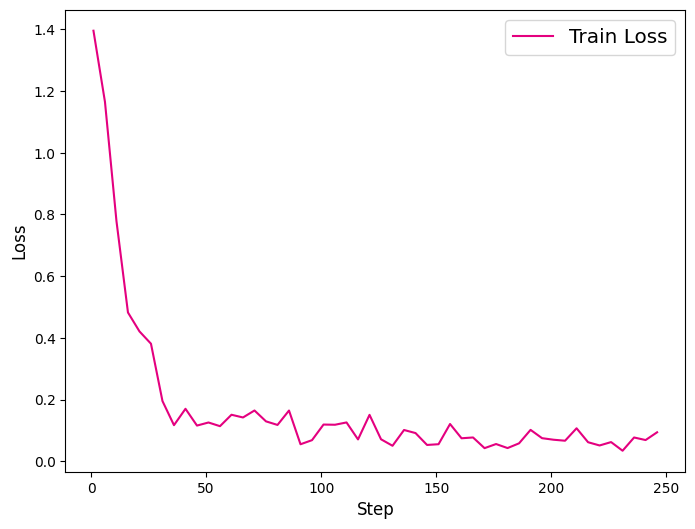

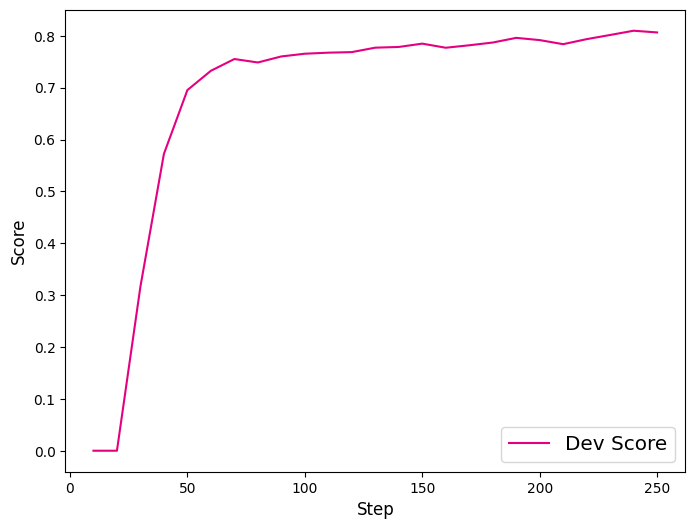

In [8]:
import matplotlib.pyplot as plt

def plot_training_loss(train_loss_record, fig_name, fig_size=(8, 6), sample_step=10, loss_legend_loc="lower left"):
    """
    绘制损失变化图

    输入:
        - train_loss_record: 训练过程中的损失记录
        - fig_name: 图片保存路径
        - fig_size: 设置图像尺寸
        - sample_step: 每隔sample_step会采样一个损失点，用以绘制图像
        - loss_legend_loc: 图例说明的位置
    """
    plt.figure(figsize=fig_size)

    train_steps = [x[0] for x in train_loss_record][::sample_step]
    train_losses = [x[1] for x in train_loss_record][::sample_step]

    plt.plot(train_steps, train_losses, color='#e4007f', label="Train Loss")
    # 绘制坐标轴和图例
    plt.ylabel("Loss", fontsize='large')
    plt.xlabel("Step", fontsize='large')
    plt.legend(loc=loss_legend_loc, fontsize='x-large')

    plt.savefig(fig_name)
    plt.show()

def plot_training_acc(train_score_record, fig_name, fig_size=(8, 6), sample_step=10, acc_legend_loc="lower left"):
    """
    绘制评估分数变化图

    输入:
        - train_score_record: 训练过程中的评估分数记录
        - fig_name: 图片保存路径
        - fig_size: 设置图像尺寸
        - sample_step: 每隔sample_step会采样一个损失点，用以绘制图像
        - acc_legend_loc: 图例说明的位置
    """
    plt.figure(figsize=fig_size)

    train_steps=[x[0] for x in train_score_record]
    train_losses = [x[1] for x in train_score_record]

    plt.plot(train_steps, train_losses, color='#e4007f', label="Dev Score")
    # 绘制坐标轴和图例
    plt.ylabel("Score", fontsize='large')
    plt.xlabel("Step", fontsize='large')
    plt.legend(loc=acc_legend_loc, fontsize='x-large')

    plt.savefig(fig_name)
    plt.show()


fig_path = "./images/chapter7_loss.pdf"
plot_training_loss(train_loss_record, fig_path, loss_legend_loc="upper right", sample_step=5)

fig_path = "./images/chapter7_acc.pdf"
plot_training_acc(train_score_record, fig_path, sample_step=1, acc_legend_loc="lower right")

In [9]:
def predict(input_text, ext_model, tokenizer, ext_id2label, max_seq_len=512):
    encoded_inputs = tokenizer(list(input_text), is_split_into_words=True, max_seq_len=max_seq_len,)
    input_ids = paddle.to_tensor([encoded_inputs["input_ids"]])
    token_type_ids = paddle.to_tensor([encoded_inputs["token_type_ids"]])

    logits = ext_model(input_ids, token_type_ids=token_type_ids)
    predictions = logits.argmax(axis=2).numpy()
    print(predictions.shape)
    predictions = predictions[0]
    tag_seq = [ext_id2label[idx] for idx in predictions][1:-1]
    
    print("text: ", input_text)
    print("预测结果: ", tag_seq)

max_seq_len = 512

input_text = "蛋糕的味道不错，很棒，店家的服务也很热情"
predict(input_text, ext_model, tokenizer, ext_id2label,  max_seq_len=max_seq_len)

(1, 22)
text:  蛋糕的味道不错，很棒，店家的服务也很热情
预测结果:  ['B-Aspect', 'O', 'O', 'B-Aspect', 'I-Aspect', 'B-Opinion', 'I-Opinion', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-Aspect', 'I-Aspect', 'O', 'O', 'B-Opinion', 'I-Opinion']


/home/ricaedo/下载/yes/envs/paddle/lib/python3.10/site-packages/paddlenlp/transformers/tokenizer_utils_base.py:2353: FutureWarning: The `max_seq_len` argument is deprecated and will be removed in a future version, please use `max_length` instead.
  warnings.warn(
/home/ricaedo/下载/yes/envs/paddle/lib/python3.10/site-packages/paddlenlp/transformers/tokenizer_utils_base.py:1925: UserWarning: Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
  warnings.warn(
